<table style="border: none; border-collapse: collapse;">
    <tr>
        <td style="width: 20%; vertical-align: middle; padding-right: 10px;">
            <img src="https://i.imgur.com/cGOOUZw.png" width="120">
        </td>
        <td style="width: 2px; text-align: center;">
            <font color="#1957d1" size="7">|</font><br>
            <font color="#1957d1" size="7">|</font>
        </td>
        <td>
            <p style="font-variant: small-caps;"><font color="#1957d1" size="5">
                <b>Revisión Sistemática PRISMA</b>
            </font></p>
            <p style="font-variant: small-caps;"><font color="#1957d1" size="4">
                Screening Fase 2: Texto Completo
            </font></p>
            <p style="font-style: oblique;"><font color="#1957d1" size="3">
                Francisco Flores &bull; Marzo 2026
            </font></p>
        </td>
    </tr>
</table>

Este notebook automatiza el **screening PRISMA Fase 2** (evaluación de texto completo) sobre los 101 artículos que superaron la Fase 1. Utiliza la API de Anthropic con el modelo Claude Sonnet 4.6.

**Metodología:**
- Lectura automática de PDFs completos mediante PyMuPDF
- Evaluación mediante 5 preguntas de elegibilidad via tool use estructurado
- Sistema de decisión con criterios eliminatorios y revisión manual para Q3

**Preguntas de elegibilidad:**
1. ¿Reporta métricas cuantitativas de performance orientadas a calidad de resultados?
2. ¿Aplica al menos una técnica en scope con evidencia real de implementación?
3. ¿Identifica el dataset utilizado con nombre o descripción suficiente del corpus?
4. ¿Especifica la tarea realizada Y el modelo base utilizado?
5. ¿Es un estudio empírico original que reporta sus propios resultados experimentales?

**Sistema de decisión:**
- `INCLUIR`: Q1, Q2, Q4, Q5 en True y Q3 en True
- `REVISAR`: Q1, Q2, Q4, Q5 en True pero Q3 en False — requiere revisión manual
- `EXCLUIR`: Q1, Q2, Q4 o Q5 en False (criterio eliminatorio)

## <font color='1957d1'>Configuración Inicial</font>

Importación de librerías y configuración del cliente Anthropic.

In [1]:
# - Importar librerías y configurar cliente Anthropic -

import pandas as pd
import numpy as np
import anthropic
import fitz  # PyMuPDF
import json
import time
from pathlib import Path
import matplotlib.pyplot as plt
from pydantic import BaseModel
import warnings
import os
from dotenv import load_dotenv

warnings.filterwarnings('ignore')

load_dotenv()
api_key = os.getenv("ANTHROPIC_API_KEY")

if not api_key:
    raise ValueError("No se encontró ANTHROPIC_API_KEY en el archivo .env")

client = anthropic.Anthropic(api_key=api_key)
print(f"Cliente Anthropic configurado correctamente")

Cliente Anthropic configurado correctamente


## <font color='1957d1'>Modelo de Respuesta Estructurada</font>

Esquema Pydantic para las 5 preguntas de elegibilidad. Se usa como estructura de validación interna — la API de Anthropic retorna los campos via tool use, que luego se mapean a este modelo para mantener compatibilidad con el resto del pipeline.

In [2]:
# - Definir esquema de respuesta estructurada para las 5 preguntas de elegibilidad -

class EvaluacionFase2(BaseModel):
    """
    Esquema de respuesta para evaluación de texto completo.
    Q1, Q2, Q4, Q5 son criterios eliminatorios — False en cualquiera → EXCLUIR.
    Q3 es no eliminatorio — False → REVISAR (revisión manual).
    """
    q1_metricas_performance: bool
    q2_tecnica_implementacion: bool
    q3_dataset_identificado: bool
    q4_contexto_evaluacion: bool
    q5_estudio_empirico: bool
    razon_exclusion: str  # Vacío si todos los criterios se cumplen

## <font color='1957d1'>Función de Lectura de PDFs</font>

Extracción de texto completo desde archivos PDF usando PyMuPDF.

In [3]:
# - Extracción de texto completo desde PDF -

def extract_text_from_pdf(pdf_path, max_pages=None):
    """
    Extrae texto completo de un PDF priorizando secciones
    relevantes para evaluación de elegibilidad PRISMA.

    Args:
        pdf_path: Ruta al archivo PDF
        max_pages: Límite de páginas (None = todas)

    Returns:
        str: Texto extraído, o None si el PDF no tiene texto extraíble
    """
    doc = fitz.open(pdf_path)
    int_total_pages = len(doc)
    int_pages_to_process = min(int_total_pages, max_pages) if max_pages else int_total_pages

    lst_pages_text = [doc[i].get_text() for i in range(int_pages_to_process)]
    doc.close()

    str_full_text = "\n".join(lst_pages_text)

    if len(str_full_text.strip()) < 100:
        return None  # PDF escaneado sin OCR

    return str_full_text

## <font color='1957d1'>Prompt del Sistema y Tool Schema</font>

Definición del system prompt optimizado para Claude y el esquema de tool use que fuerza respuestas estructuradas. Claude no usa `response_format` con Pydantic como OpenAI — en su lugar, el tool use con `tool_choice: any` garantiza que el modelo siempre llame al tool y retorne los campos requeridos.

In [4]:
# - Definir system prompt y tool schema para evaluación estructurada -

SYSTEM_PROMPT = """You are a rigorous evaluator for a systematic literature review (PRISMA methodology) on fine-tuning techniques for Large Language Models (LLMs). 

Your evaluation must be STRICT and CONSERVATIVE. When evidence is ambiguous or insufficient, default to False.

You will read the full text of a research paper and evaluate it against 5 eligibility criteria. For each criterion, you must find explicit, direct evidence in the text — do not infer or assume.

EVALUATION CRITERIA:

Q1 — Quantitative performance metrics:
  TRUE if: The paper reports explicit numerical results using accuracy, F1, precision, recall, BLEU, ROUGE, METEOR, exact match, perplexity, or standard benchmark scores (MMLU, HellaSwag, TruthfulQA, HumanEval, GSM8K, SQuAD, etc.)
  FALSE if: Results are only qualitative, only computational (training time, memory, FLOPs, GPU usage), or only human evaluation without numerical scores.

Q2 — In-scope fine-tuning technique with real implementation:
  TRUE if: The paper explicitly trains or fine-tunes a model using at least one of: Full Fine-Tuning, LoRA, QLoRA, Adapter layers, Prefix Tuning, RLHF, or DPO — AND provides evidence of actual application (optimizer used, dataset applied, training steps or epochs reported). Specific hyperparameters like LoRA rank are NOT required.
  FALSE if: The technique is only cited or mentioned in a literature review context without actual implementation, or the technique is outside the list above, or the fine-tuning is applied exclusively to a non-NLP task (e.g., geophysical data reconstruction, time series numerical prediction, image processing, or any task where the input and output are not natural language).

Q3 — Dataset identification:
  TRUE if: The paper explicitly names the dataset used AND specifies at least the application domain or task context (e.g., "SQuAD for reading comprehension", "MIMIC-III for clinical NLP"). Internal/proprietary datasets are acceptable if the domain and task are clearly described.
  FALSE if: No dataset is identified, or the reference is too vague to understand what data was used (e.g., "we used an internal dataset" with no further description).

Q4 — Evaluation context specification:
  TRUE if: The paper explicitly states BOTH (a) an NLP task performed — such as classification, summarization, question answering, code generation, translation, dialogue, named entity recognition, sentiment analysis, or any task where the input and/or output is natural language — AND (b) the base model architecture used (LLaMA, GPT-2, Mistral, BERT, T5, Falcon, BLOOM, etc.).
  FALSE if: Either the task OR the base model is missing or ambiguous. Also FALSE if the task is not an NLP task — numerical regression, time series prediction, image processing, geophysical data reconstruction, sensor data analysis, or any non-linguistic task does NOT qualify, even if the base model is an LLM architecture.

Q5 — Original empirical study:
  TRUE if: This is primary research that trains or fine-tunes a model and reports its own experimental results obtained by the authors.
  FALSE if: Survey, literature review, purely theoretical paper, position paper, or a paper that only reproduces or summarizes results from other studies without its own experiments.

After evaluation, call the `registrar_evaluacion` tool with your assessment. If any criterion is False, provide a concise explanation (1-2 sentences in English) in the `razon_exclusion` field identifying which criterion failed and why. If all criteria are True, leave `razon_exclusion` as an empty string."""


EVALUATION_TOOL = {
    "name": "registrar_evaluacion",
    "description": "Registra la evaluación de elegibilidad PRISMA del paper según los 5 criterios de inclusión/exclusión.",
    "input_schema": {
        "type": "object",
        "properties": {
            "q1_metricas_performance": {
                "type": "boolean",
                "description": "TRUE si el paper reporta métricas cuantitativas de performance orientadas a calidad de resultados."
            },
            "q2_tecnica_implementacion": {
                "type": "boolean",
                "description": "TRUE si el paper aplica al menos una técnica de fine-tuning en scope con evidencia real de implementación en una tarea NLP."
            },
            "q3_dataset_identificado": {
                "type": "boolean",
                "description": "TRUE si el paper identifica el dataset con nombre y dominio/tarea suficientes para ser rastreado."
            },
            "q4_contexto_evaluacion": {
                "type": "boolean",
                "description": "TRUE si el paper especifica TANTO una tarea NLP (clasificación, QA, summarization, generación de código, traducción, diálogo, etc.) COMO el modelo base utilizado. FALSE si la tarea no es NLP aunque el modelo base sea un LLM."
            },
            "q5_estudio_empirico": {
                "type": "boolean",
                "description": "TRUE si es un estudio empírico original que reporta sus propios resultados experimentales."
            },
            "razon_exclusion": {
                "type": "string",
                "description": "Razón de exclusión si algún criterio es False. Vacío si todos son True."
            }
        },
        "required": [
            "q1_metricas_performance",
            "q2_tecnica_implementacion",
            "q3_dataset_identificado",
            "q4_contexto_evaluacion",
            "q5_estudio_empirico",
            "razon_exclusion"
        ]
    }
}

## <font color='1957d1'>Función de Evaluación</font>

Envía el texto completo del PDF a Claude Sonnet 4.6 y retorna un objeto `EvaluacionFase2` con los resultados estructurados.

In [5]:
# - Función de evaluación via Anthropic API con tool use -

MODEL = "claude-sonnet-4-6"

def evaluate_paper(pdf_text, title, model=MODEL):
    """
    Evalúa un paper completo usando Claude via tool use estructurado.

    Args:
        pdf_text: Texto completo extraído del PDF
        title: Título del paper
        model: Modelo de Anthropic a utilizar

    Returns:
        EvaluacionFase2 object, o None si no se obtuvo respuesta del tool
    """
    str_user_prompt = f"""Paper Title: {title}

Full Text:
{pdf_text}

Evaluate this paper against the 5 PRISMA eligibility criteria and call the registrar_evaluacion tool with your assessment."""

    response = client.messages.create(
        model=model,
        max_tokens=1024,
        system=SYSTEM_PROMPT,
        tools=[EVALUATION_TOOL],
        tool_choice={"type": "any"},  # Fuerza uso del tool en cada llamada
        messages=[{"role": "user", "content": str_user_prompt}]
    )

    # Extraer bloque tool_use del response
    tool_block = next(
        (block for block in response.content if block.type == "tool_use"),
        None
    )

    if tool_block is None:
        return None

    dic_data = tool_block.input

    return EvaluacionFase2(
        q1_metricas_performance=dic_data["q1_metricas_performance"],
        q2_tecnica_implementacion=dic_data["q2_tecnica_implementacion"],
        q3_dataset_identificado=dic_data["q3_dataset_identificado"],
        q4_contexto_evaluacion=dic_data["q4_contexto_evaluacion"],
        q5_estudio_empirico=dic_data["q5_estudio_empirico"],
        razon_exclusion=dic_data.get("razon_exclusion", "")
    )

## <font color='1957d1'>Función de Decisión Final</font>

Sistema de decisión con criterios eliminatorios. Q1, Q2, Q4 y Q5 son eliminatorios directos. Q3 genera revisión manual en lugar de exclusión automática.

In [6]:
# - Función de decisión final con criterios eliminatorios -

def decide_inclusion(evaluation):
    """
    Determina la decisión final basada en los criterios eliminatorios PRISMA.

    Q1, Q2, Q4, Q5: eliminatorios — False en cualquiera → EXCLUIR
    Q3: no eliminatorio — False → REVISAR (revisión manual)
    Todas True → INCLUIR

    Returns:
        tuple: (decision: str, yes_count: int)
    """
    if evaluation is None:
        return ('ERROR', 0)

    int_yes_count = sum([
        evaluation.q1_metricas_performance,
        evaluation.q2_tecnica_implementacion,
        evaluation.q3_dataset_identificado,
        evaluation.q4_contexto_evaluacion,
        evaluation.q5_estudio_empirico,
    ])

    if not evaluation.q1_metricas_performance:
        return ('EXCLUIR', int_yes_count)
    if not evaluation.q2_tecnica_implementacion:
        return ('EXCLUIR', int_yes_count)
    if not evaluation.q4_contexto_evaluacion:
        return ('EXCLUIR', int_yes_count)
    if not evaluation.q5_estudio_empirico:
        return ('EXCLUIR', int_yes_count)
    if not evaluation.q3_dataset_identificado:
        return ('REVISAR', int_yes_count)

    return ('INCLUIR', int_yes_count)

## <font color='1957d1'>Carga de PDFs</font>

Identificación de los archivos PDF disponibles en el directorio de datos. Los PDFs corresponden a los 101 papers que superaron el screening de Fase 1.

In [8]:
# - Identificar PDFs disponibles para evaluación -

PDF_DIR = Path("Data/Pdfs-Fase1")

if not PDF_DIR.exists():
    raise ValueError(f"Directorio {PDF_DIR} no existe. Crea la carpeta y coloca los PDFs de Fase 1.")

lst_available_pdfs = list(PDF_DIR.glob("*.pdf"))

if len(lst_available_pdfs) == 0:
    raise ValueError(f"No se encontraron PDFs en {PDF_DIR}.")

print(f"PDFs encontrados: {len(lst_available_pdfs)}")

df = pd.DataFrame({
    'pdf_filename': [pdf.name for pdf in lst_available_pdfs],
    'pdf_path': [str(pdf) for pdf in lst_available_pdfs]
})

PDFs encontrados: 101


### <font color='1957d1'>Configuración de Ejecución</font>

Selección del modo de procesamiento. `SAMPLE_SIZE = None` procesa todos los PDFs. Cambiar a un entero (e.g., `5`) para modo TEST antes de correr producción.

In [9]:
# - Configurar modo de ejecución -

SAMPLE_SIZE = None  # TEST: N entero | Producción: None

if SAMPLE_SIZE:
    df_screen = df.head(SAMPLE_SIZE).copy()
    print(f"Modo TEST: {SAMPLE_SIZE} PDFs")
else:
    df_screen = df.copy()
    print(f"Modo PRODUCCIÓN: {len(df_screen)} PDFs")

df_screen['q1_metricas']      = None
df_screen['q2_tecnica']       = None
df_screen['q3_dataset']       = None
df_screen['q4_contexto']      = None
df_screen['q5_empirico']      = None
df_screen['razon_exclusion']  = ''
df_screen['yes_count']        = 0
df_screen['decision_final']   = ''
df_screen['extraction_error'] = False

Modo PRODUCCIÓN: 101 PDFs


## <font color='1957d1'>Ejecución del Screening</font>

Procesamiento secuencial de cada PDF: extracción de texto completo, evaluación mediante Claude Sonnet 4.6, y registro de resultados según las 5 preguntas de elegibilidad PRISMA.

El loop incluye un sistema de **checkpoint automático** que guarda el progreso después de cada paper. Si la ejecución se interrumpe, al volver a correr el notebook retoma desde el último paper procesado sin repetir llamadas a la API.

**Configuración del `time.sleep`:**
- `time.sleep(1)` — uso general, modelos pequeños o contextos cortos
- `time.sleep(3)` — recomendado para Sonnet con papers de tamaño normal
- `time.sleep(60)` — necesario cuando el rate limit de la organización es bajo (e.g., 30,000 tokens/min). A ~20,000 tokens por paper, procesar más de 1 paper por minuto excede el límite. Ajustar según el tier de la API key.

El loop original sin checkpoint se conserva comentado al final de esta sección como referencia del pipeline inicial.

In [ ]:
# - Loop original sin checkpoint — conservado como referencia -

int_total = len(df_screen)

for idx, row in df_screen.iterrows():
    str_filename = row['pdf_filename']
    str_pdf_path = row['pdf_path']
    str_title    = str_filename.replace('.pdf', '')

    print(f"Procesando [{df_screen.index.get_loc(idx)+1}/{int_total}]: {str_filename}")
    str_pdf_text = extract_text_from_pdf(str_pdf_path)

    if str_pdf_text is None:
        print(f"  → ERROR: PDF sin texto extraíble (posiblemente escaneado)")
        df_screen.at[idx, 'decision_final']   = 'ERROR'
        df_screen.at[idx, 'extraction_error'] = True
        continue

    evaluation = evaluate_paper(str_pdf_text, str_title)
    str_decision, int_yes = decide_inclusion(evaluation)

    df_screen.at[idx, 'q1_metricas']      = evaluation.q1_metricas_performance if evaluation else None
    df_screen.at[idx, 'q2_tecnica']       = evaluation.q2_tecnica_implementacion if evaluation else None
    df_screen.at[idx, 'q3_dataset']       = evaluation.q3_dataset_identificado if evaluation else None
    df_screen.at[idx, 'q4_contexto']      = evaluation.q4_contexto_evaluacion if evaluation else None
    df_screen.at[idx, 'q5_empirico']      = evaluation.q5_estudio_empirico if evaluation else None
    df_screen.at[idx, 'razon_exclusion']  = evaluation.razon_exclusion if evaluation else 'API error'
    df_screen.at[idx, 'yes_count']        = int_yes
    df_screen.at[idx, 'decision_final']   = str_decision

    if str_decision == 'EXCLUIR':
        str_razon = evaluation.razon_exclusion if evaluation else 'Sin evaluación'
        print(f"  → EXCLUIDO: {str_razon}")
    elif str_decision == 'REVISAR':
        str_razon = evaluation.razon_exclusion if evaluation else ''
        print(f"  → REVISAR (Q3 dataset no identificado): {str_razon}")

    time.sleep(60)

print(f"\nScreening completado: {int_total} papers procesados")

## <font color='1957d1'>Resumen de Resultados</font>

Distribución de decisiones finales y estadísticas de consenso por pregunta.

In [16]:
# - Resumen de resultados del screening -

df_valid = df_screen[df_screen['decision_final'] != 'ERROR']

int_incluir = (df_valid['decision_final'] == 'INCLUIR').sum()
int_revisar = (df_valid['decision_final'] == 'REVISAR').sum()
int_excluir = (df_valid['decision_final'] == 'EXCLUIR').sum()
int_error   = (df_screen['decision_final'] == 'ERROR').sum()

print(f"Total procesados: {len(df_screen)}")
print(f"INCLUIR:  {int_incluir}")
print(f"REVISAR:  {int_revisar}")
print(f"EXCLUIR:  {int_excluir}")
print(f"ERROR:    {int_error}")

Total procesados: 101
INCLUIR:  85
REVISAR:  0
EXCLUIR:  16
ERROR:    0


## <font color='1957d1'>Visualización de Resultados</font>

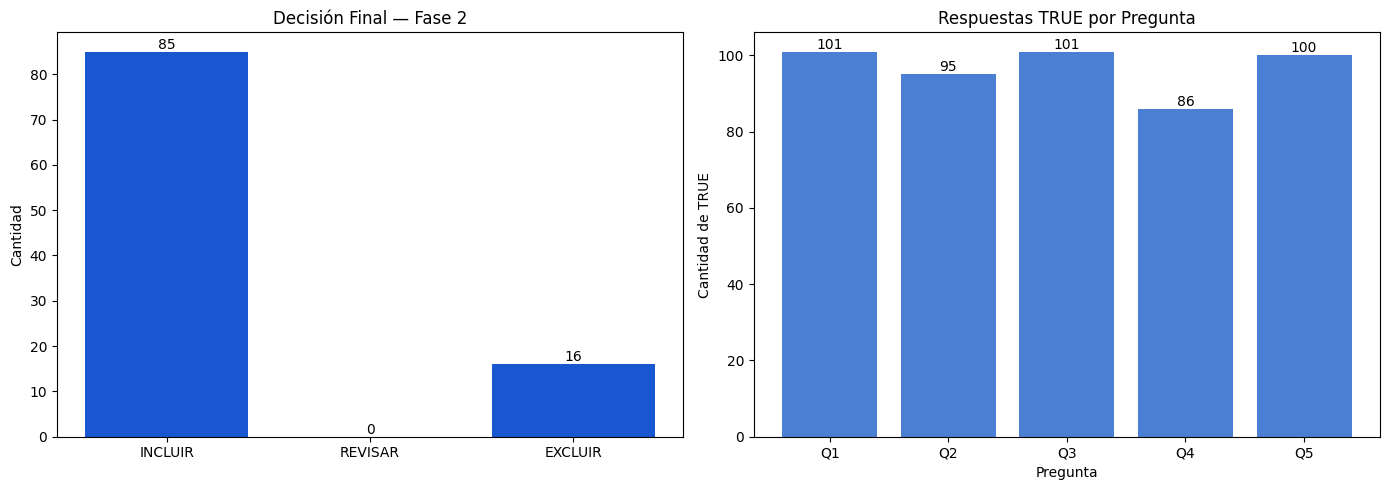

In [17]:
# - Gráficos de distribución de decisiones y respuestas por pregunta -

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

decision_counts = df_valid['decision_final'].value_counts().reindex(
    ['INCLUIR', 'REVISAR', 'EXCLUIR'], fill_value=0
)
bars1 = axes[0].bar(decision_counts.index, decision_counts.values, color='#1957d1')
axes[0].set_title('Decisión Final — Fase 2')
axes[0].set_ylabel('Cantidad')
for bar in bars1:
    height = bar.get_height()
    axes[0].text(bar.get_x() + bar.get_width()/2., height,
                f'{int(height)}', ha='center', va='bottom')

lst_preguntas_labels = ['Q1', 'Q2', 'Q3', 'Q4', 'Q5']
lst_preguntas_cols   = ['q1_metricas', 'q2_tecnica', 'q3_dataset', 'q4_contexto', 'q5_empirico']
lst_yes_counts = [df_valid[col].sum() for col in lst_preguntas_cols]
bars2 = axes[1].bar(lst_preguntas_labels, lst_yes_counts, color='#4a7fd4')
axes[1].set_title('Respuestas TRUE por Pregunta')
axes[1].set_ylabel('Cantidad de TRUE')
axes[1].set_xlabel('Pregunta')
for bar in bars2:
    height = bar.get_height()
    axes[1].text(bar.get_x() + bar.get_width()/2., height,
                f'{int(height)}', ha='center', va='bottom')

plt.tight_layout()
plt.show();

## <font color='1957d1'>Exportación de Resultados</font>

Generación del archivo CSV con los resultados completos del screening de Fase 2 para documentación PRISMA y revisión manual de los casos REVISAR.

In [18]:
# - Exportar resultados del screening Fase 2 -

EXPORT_DIR = Path("Exports/Phase2")
EXPORT_DIR.mkdir(parents=True, exist_ok=True)

df_export = df_screen[[
    'pdf_filename',
    'q1_metricas',
    'q2_tecnica',
    'q3_dataset',
    'q4_contexto',
    'q5_empirico',
    'razon_exclusion',
    'yes_count',
    'decision_final',
    'extraction_error'
]].copy()

str_output_file = EXPORT_DIR / "phase2_screening_results.csv"
df_export.to_csv(str_output_file, index=False)

print(f"Resultados exportados a: {str_output_file}")
print(f"Total de registros: {len(df_export)}")
print(f"\nDistribución de decisiones:")
print(df_export['decision_final'].value_counts())

Resultados exportados a: Exports\Phase2\phase2_screening_results.csv
Total de registros: 101

Distribución de decisiones:
decision_final
INCLUIR    85
EXCLUIR    16
Name: count, dtype: int64
